# TP3 (a completer) : Regression lineaire — *California Housing*

Remplacez chaque `...` et chaque `# TODO`. Corrige :
`../notebooks/TP3_regression_lineaire.ipynb`.

**Objectif.** Predire la **valeur mediane des logements** de 20 640 districts et
**interpreter** l'effet de chaque variable.

In [1]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [2]:
from sklearn.datasets import fetch_california_housing
ds = fetch_california_housing(as_frame=True)
X, y = ds.data, ds.target.rename("prix")   # prix en x100 000 USD
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1. Exploration
**Consigne.** Affichez la correlation de chaque variable avec `prix`, triee.

In [3]:
# TODO : correlations avec le prix (indice : pd.concat([X, y], axis=1).corr())
corr = pd.concat([X, y], axis=1).corr()
correlations = corr["prix"].drop("prix").sort_values(ascending=False)
print(correlations)

MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: prix, dtype: float64


## 2. Modelisation
**Consigne.** Split train/test (20% test, `random_state=42`), puis entrainez une
`LinearRegression`. Affichez l'ordonnee a l'origine et les coefficients.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modele = LinearRegression().fit(X_train, y_train)        # TODO : entrainer la regression
# TODO : afficher intercept_ et coef_
print("Ordonnee a l'origine (intercept) :", modele.intercept_)
print("Coefficients :")
print(pd.Series(modele.coef_, index=X.columns))

Ordonnee a l'origine (intercept) : -37.02327770606405
Coefficients :
MedInc        0.448675
HouseAge      0.009724
AveRooms     -0.123323
AveBedrms     0.783145
Population   -0.000002
AveOccup     -0.003526
Latitude     -0.419792
Longitude    -0.433708
dtype: float64


## 3. Evaluation
**Consigne.** Calculez **R2**, **RMSE** et **MAE** sur le test.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modele.predict(X_test)
# TODO : R2, RMSE (= racine de mean_squared_error), MAE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print("R2   :", r2)
print("RMSE :", rmse)
print("MAE  :", mae)

R2   : 0.5757877060324512
RMSE : 0.745581383012776
MAE  : 0.5332001304956561


## 4. Visualisation
**Consigne.** (a) Tracez `prix` vs `MedInc` avec la droite de regression simple.
(b) Tracez **predit vs reel** sur un echantillon. (c) Tracez les **residus**.

/home/este/Documents/school/intro IA/2TP/2ESGI/.tp_ml_2esgi/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


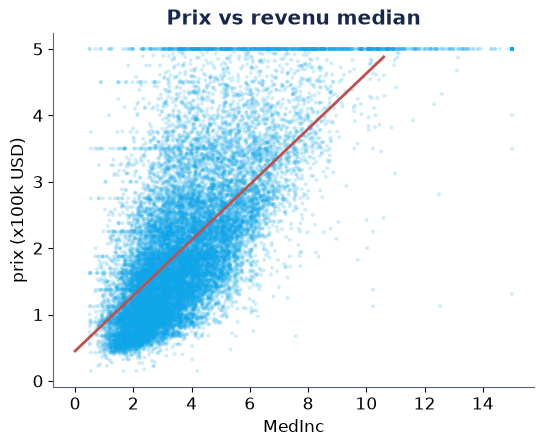

In [6]:
# (a) prix vs MedInc + droite
simple = LinearRegression().fit(X[["MedInc"]], y)
xs = np.linspace(0, X["MedInc"].quantile(0.99), 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(X["MedInc"], y, s=8, color=ACCENT, alpha=0.2, edgecolor="none")
# TODO : tracer la droite simple.predict(xs)
ax.plot(xs, simple.predict(xs), color=RED, lw=2)
ax.set(title="Prix vs revenu median", xlabel="MedInc", ylabel="prix (x100k USD)")
plt.show()

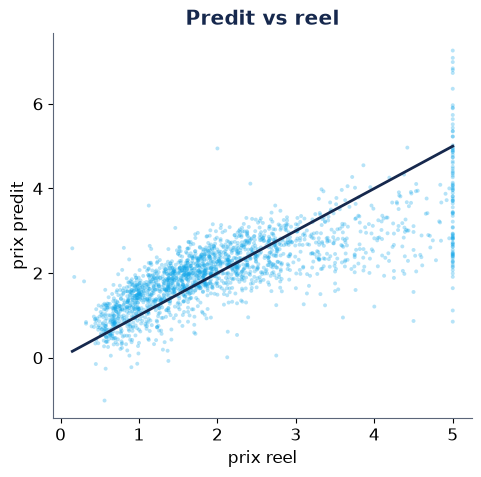

In [7]:
# (b) predit vs reel (echantillon de 2000 points)
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), 2000, replace=False)
yt, yp = y_test.to_numpy()[idx], y_pred[idx]
fig, ax = plt.subplots(figsize=(5.4, 5))
# TODO : scatter(yt, yp) + diagonale de reference
ax.scatter(yt, yp, s=8, color=ACCENT, alpha=0.3, edgecolor="none")
ax.plot([yt.min(), yt.max()], [yt.min(), yt.max()], color=NAVY, lw=2)
ax.set(title="Predit vs reel", xlabel="prix reel", ylabel="prix predit")
plt.show()

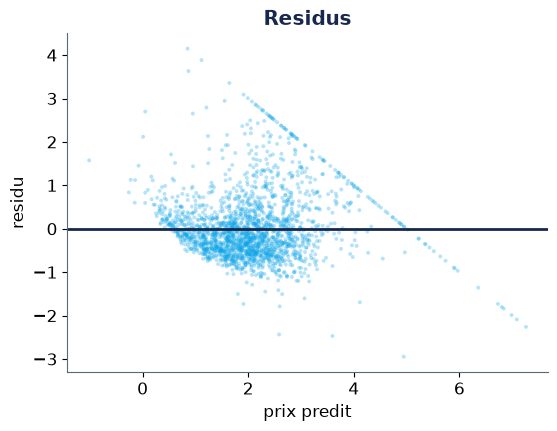

In [8]:
# (c) residus
residus = yt - yp
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.axhline(0, color=NAVY, lw=2)
# TODO : scatter(yp, residus)
ax.scatter(yp, residus, s=8, color=ACCENT, alpha=0.3, edgecolor="none")
ax.set(title="Residus", xlabel="prix predit", ylabel="residu")
plt.show()

## 5. Interpretation
**Consigne.** Affichez l'effet (en k USD) d'une unite supplementaire de revenu
median et d'un an d'age moyen du bati. Estimez le prix de 3 districts.

In [9]:
coefs = pd.Series(modele.coef_, index=X.columns)
# TODO : afficher coefs['MedInc']*100 et coefs['HouseAge']*100
print("Effet +1 de revenu median :", coefs["MedInc"] * 100, "k USD")
print("Effet +1 an d'age du bati :", coefs["HouseAge"] * 100, "k USD")
estim = X.head(3).copy()
estim["prix_estime"] = modele.predict(X.head(3))    # TODO : modele.predict(X.head(3))
estim

Effet +1 de revenu median : 44.86749096657175 k USD
Effet +1 an d'age du bati : 0.9724257517905038 k USD


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,prix_estime
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.151943
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.999520
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.673580


## A rendre
- R2, RMSE, MAE et leur interpretation.
- Ce que revele le graphique des residus (indice : effet de plafond).
- L'effet du revenu median sur le prix.

**Bonus.** Comparez le R2 avec une seule variable (`MedInc`) vs toutes.

In [10]:
# Bonus : R2 avec une seule variable (MedInc) vs toutes les variables
modele_simple = LinearRegression().fit(X_train[["MedInc"]], y_train)
r2_simple = r2_score(y_test, modele_simple.predict(X_test[["MedInc"]]))
print("R2 avec MedInc seul   :", round(r2_simple, 3))
print("R2 avec toutes les var :", round(r2, 3))

R2 avec MedInc seul   : 0.459
R2 avec toutes les var : 0.576


## Analyse finale

R2, RMSE et MAE.
- R2 = 0.576, donc le modele explique environ 58% des variations du prix. C'est pas mal pour un modele lineaire simple, mais il reste 42% qu'il n'explique pas.
- RMSE = 0.746, soit environ 74 600 USD d'erreur (cette mesure tape plus fort sur les grosses erreurs).
- MAE = 0.533, soit environ 53 300 USD d'erreur moyenne. La MAE est plus petite que la RMSE, ce qui veut dire qu'il y a quelques predictions tres fausses qui font monter la RMSE.

Ce que montrent les residus.
- Les points ne sont pas repartis au hasard autour de 0. On voit une ligne diagonale en haut : c'est l'effet de plafond.
- Les prix sont coupes a 5 (500 000 USD), donc le modele predit au dessus mais le vrai prix reste bloque, ce qui cree ces residus tres negatifs alignes. Le modele gere mal les maisons les plus cheres.

Effet du revenu median.
- Le coefficient de MedInc est le plus important. Quand le revenu median augmente d'une unite, le prix predit monte d'environ +44,9 k USD.
- C'est logique : plus les gens du quartier gagnent, plus les logements sont chers.

Bonus (MedInc seul vs toutes les variables).
- R2 avec MedInc seul = 0.459, R2 avec toutes les variables = 0.576.
- Le revenu median explique deja presque la moitie du prix. Ajouter les autres variables gagne environ 12 points de R2 : elles aident, mais beaucoup moins que MedInc.